# Isotopic ratios — simplified PySDM reproduction notebook

This is a minimal, functional rewrite of the Zaba et al. isotopic ratios example.


In [1]:
import numpy as np
from matplotlib import pyplot
from matplotlib.ticker import FuncFormatter

from PySDM import Builder
from PySDM.environments import Box
from PySDM.backends import CPU
from PySDM.dynamics import Condensation, IsotopicFractionation
from PySDM import Formulae
from PySDM.physics.constants import si, PER_MILLE, in_unit, PER_CENT
from PySDM.dynamics.isotopic_fractionation import HEAVY_ISOTOPES

In [2]:
class Simulation:

    @staticmethod
    def make_particulator(
        *,
        ff,
        molecular_isotopic_ratio,
        initial_R_vap,
        attributes,
        n_sd,
        dv,
        dt,
        relative_humidity,
        T,
        isotope,
    ):
        const = ff.constants

        if isotope == "2H":
            molar_mass_heavy = const.M_2H_1H_16O
        else:
            molar_mass_heavy = getattr(const, f"M_1H2_{isotope}")

        for iso in HEAVY_ISOTOPES:
            attributes[f"moles_{iso}"] = 0.0
        attributes[f"moles_{isotope}"] = ff.trivia.moles_heavy_atom(
            mass_total=attributes["signed water mass"],
            mass_other_heavy_isotopes=0,
            molar_mass_light_molecule=const.M_1H2_16O,
            molar_mass_heavy_molecule=molar_mass_heavy,
            molecular_isotopic_ratio=molecular_isotopic_ratio,
        )

        builder = Builder(
            n_sd=n_sd,
            backend=CPU(formulae=ff),
            environment=Box(dv=dv, dt=dt),
        )

        builder.add_dynamic(Condensation())
        builder.add_dynamic(IsotopicFractionation(isotopes=(isotope,)))

        rho_d = const.p_STP / const.Rd / T
        
        initial_conc_vap = (
            ff.saturation_vapour_pressure.pvs_water(T)
            * relative_humidity
            / const.R_str
            / T
        )

        molality = ff.trivia.molality_in_dry_air(
            isotopic_fraction=ff.trivia.isotopic_fraction_assuming_single_heavy_isotope(isotopic_ratio=initial_R_vap),
            density_dry_air=rho_d,
            total_vap_concentration=initial_conc_vap,
        )
        
        for iso in HEAVY_ISOTOPES:
            if iso == isotope:
                builder.particulator.environment[f"molality {iso} in dry air"] = (
                    molality
                )
            else:
                builder.particulator.environment[f"molality {iso} in dry air"] = 0
        builder.particulator.environment["rhod"] = rho_d
        builder.particulator.environment["RH"] = relative_humidity
        builder.particulator.environment["T"] = T

        builder.request_attribute(f"delta_{isotope}")
        # builder.request_attribute(f"Bolin number for {isotope}")

        particulator = builder.build(attributes=attributes, products=())
        
        return particulator, initial_conc_vap

    @staticmethod
    def do_one_step(
        *,
        ff,
        particulator,
        dm_dt_per_droplet,
        init_m_R_liq,
        initial_conc_vap,
        isotope,
    ):

        if isotope == "2H":
            light_isotope = "1H"
            atoms_per_light = 2
        else:
            light_isotope = "16O"
            atoms_per_light = 1

        isotopic_fraction = ff.trivia.isotopic_fraction(
            particulator.environment[f"molality {isotope} in dry air"][0],
            particulator.environment["rhod"][0],
            initial_conc_vap,
        )

        R_vap = ff.trivia.isotopic_ratio_assuming_single_heavy_isotope(
            isotopic_fraction=isotopic_fraction
        )

        initial_R_liq = (
            particulator.attributes[f"moles_{isotope}"][0]
            / particulator.attributes[f"moles_{light_isotope}"][0]
        )
        
        # np.testing.assert_approx_equal(
        #     initial_R_liq,
        #     init_m_R_liq / atoms_per_light,
        #     significant=4,
        # )

        init_Bo = particulator.attributes[f"Bolin number for {isotope}"][0]

        particulator.attributes["diffusional growth mass change"].data[:] = (
            dm_dt_per_droplet * particulator.dt
        )
        particulator.dynamics["IsotopicFractionation"]()
        
        total_vap_conc = (
            initial_conc_vap
            - dm_dt_per_droplet
            * particulator.dt
            * particulator.attributes["multiplicity"][0]
            / ff.constants.Mv
            / particulator.environment.mesh.dv
        )
        new_isotopic_fraction = ff.trivia.isotopic_fraction(
            particulator.environment[f"molality {isotope} in dry air"][0],
            particulator.environment["rhod"][0],
            total_vap_conc,
        )

        new_R_vap = ff.trivia.isotopic_ratio_assuming_single_heavy_isotope(
            isotopic_fraction=new_isotopic_fraction
        )
        
        new_R_liq = (
            particulator.attributes[f"moles_{isotope}"][0]
            / particulator.attributes[f"moles_{light_isotope}"][0]
        )
        dR_dt_vap = (new_R_vap - R_vap) / particulator.dt
        dR_dt_liq = (new_R_liq - initial_R_liq) / particulator.dt
        return dR_dt_vap, dR_dt_liq, init_Bo


In [3]:
def run_cell(ff, ATTR, rh, m_R_liq, volume, T, iso, n_sd):
    delta_v = -200 * PER_MILLE
    const = ff.constants
    ISO_RATIO_V = ff.trivia.isotopic_delta_2_ratio(delta_v, const.VSMOW_R_2H)
    part, Rv0 = Simulation.make_particulator(
        ff=ff,
        molecular_isotopic_ratio=m_R_liq,
        initial_R_vap=ISO_RATIO_V,
        attributes=ATTR,
        n_sd=n_sd,
        dv=volume,
        dt=6 * si.s,
        relative_humidity=rh,
        T=T,
        isotope=iso,
    )
    pvs = ff.saturation_vapour_pressure.pvs_water(T)
    Fk = ff.drop_growth.Fk(
            T=T,
            K=const.K0,
            lv=ff.latent_heat_vapourisation.lv(T),
        )
    Fd = ff.drop_growth.Fd(
            pvs=pvs,
            T=T,
            D=const.D0,
        )
    c = (
            4 * np.pi * const.rho_w
            / (Fk + Fd)
        )
    return Simulation.do_one_step(
        ff=ff,
        particulator=part,
        dm_dt_per_droplet=c * radius * (rh - 1),
        init_m_R_liq=m_R_liq,
        initial_conc_vap=Rv0,
        isotope=iso,
    )


def run_grid(ff, ATTR, grid_rh, grid_R, volume, T, iso, n_sd):
    nn = len(grid_rh)
    vap = np.zeros((nn, nn))
    liq = np.zeros((nn, nn))
    Bo = np.zeros((nn, nn))

    for i, rh in enumerate(grid_rh):
        for j, R in enumerate(grid_R):
            vap[i, j], liq[i, j], Bo[i, j] = run_cell(
                ff, ATTR, rh, R, volume, T, iso, n_sd
            )

    return vap, liq, Bo


In [4]:
iso = "2H"
T = 283.15
ff = Formulae(
    isotope_diffusivity_ratios="HellmannAndHarvey2020+GrahamsLaw",
    isotope_equilibrium_fractionation_factors="VanHook1968",
    isotope_relaxation_timescale="ZabaEtAl",
)

grid_rh = np.linspace(0.0, 1.05, 32)
grid_R = np.linspace(0.8, 1.05, 32)
R_liq = grid_R * ff.constants.VSMOW_R_2H

radius = 0.5 * si.mm
volume = 1 * si.dm**3


ATTR = {"multiplicity": np.ones(1), "dry volume": np.nan, "kappa times dry volume": np.nan, "signed water mass": (
        4 / 3 * np.pi * radius ** 3 * 1000.0
)}


vap_pristine, liq_pristine, Bo_pristine = run_grid(
    ff, ATTR,
    grid_rh=grid_rh,
    grid_R=R_liq,
    volume=volume,
    T=T,
    iso=iso,
    n_sd=10,
)

vap_polluted, liq_polluted, Bo_polluted = run_grid(
    ff, ATTR,
    grid_rh=grid_rh,
    grid_R=R_liq,
    volume=volume,
    T=T,
    iso=iso,
    n_sd=30,
)


/Users/agnieszkazaba/PycharmProjects/PySDM/PySDM/backends/numba.py:57: UserWarning: Disabling Numba threading due to ARM64 CPU (atomics do not work yet)
  warnings.warn(


In [5]:

def plot_pristine_vs_polluted(
    vap_pristine, liq_pristine,
    vap_polluted, liq_polluted,
    grid_rh, grid_R,
):
    XX, YY = np.meshgrid(grid_R, grid_rh)

    all_liq = np.concatenate([liq_pristine.ravel(), liq_polluted.ravel()])
    all_vap = np.concatenate([vap_pristine.ravel(), vap_polluted.ravel()])

    liq_vmin, liq_vmax = np.nanmin(all_liq), np.nanmax(all_liq)
    vap_vmin, vap_vmax = np.nanmin(all_vap), np.nanmax(all_vap)

    fig, axs = pyplot.subplots(
        1, 2,
        figsize=(11, 6),
        subplot_kw={'projection': '3d'},
        constrained_layout=True,
    )

    fig.suptitle(
        "Pristine vs Polluted isotope evolution (shared scale)"
    )

    def format_ax(ax):
        ax.view_init(elev=45, azim=-65)
        ax.tick_params(axis='y', pad=-2)
        ax.tick_params(axis='z', pad=6)

        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{x:.2f}")
        )
        ax.zaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{x:.2e}")
        )

        ax.set_xlabel("R/R_VSMOW")
        ax.set_ylabel("RH")

    ax = axs[0]
    format_ax(ax)

    ax.set_title(r"Liquid phase")

    ax.plot_surface(
        XX, YY, liq_pristine,
        color="grey", alpha=0.18, edgecolor=None, zorder=1
    )
    ax.plot_wireframe(
        XX, YY, liq_pristine,
        color="black", alpha=0.25, linewidth=0.6, zorder=2
    )

    surf = ax.plot_surface(
        XX, YY, liq_polluted,
        cmap="viridis",
        vmin=liq_vmin, vmax=liq_vmax,
        alpha=0.65, edgecolor=None, zorder=3
    )
    ax.plot_wireframe(
        XX, YY, liq_polluted,
        color="darkgreen", alpha=0.35, linewidth=0.5, zorder=4
    )

    ax.set_zlim(liq_vmin, liq_vmax)
    ax.set_zlabel("liq signal")

    ax = axs[1]
    format_ax(ax)

    ax.set_title(r"Vapour phase")

    ax.plot_surface(
        XX, YY, vap_pristine,
        color="grey", alpha=0.18, edgecolor=None, zorder=1
    )
    ax.plot_wireframe(
        XX, YY, vap_pristine,
        color="black", alpha=0.25, linewidth=0.6, zorder=2
    )

    surf = ax.plot_surface(
        XX, YY, vap_polluted,
        cmap="plasma",
        vmin=vap_vmin, vmax=vap_vmax,
        alpha=0.65, edgecolor=None, zorder=3
    )
    ax.plot_wireframe(
        XX, YY, vap_polluted,
        color="darkred", alpha=0.35, linewidth=0.5, zorder=4
    )

    ax.set_zlim(vap_vmin, vap_vmax)
    ax.set_zlabel("vap signal")

    pyplot.show()

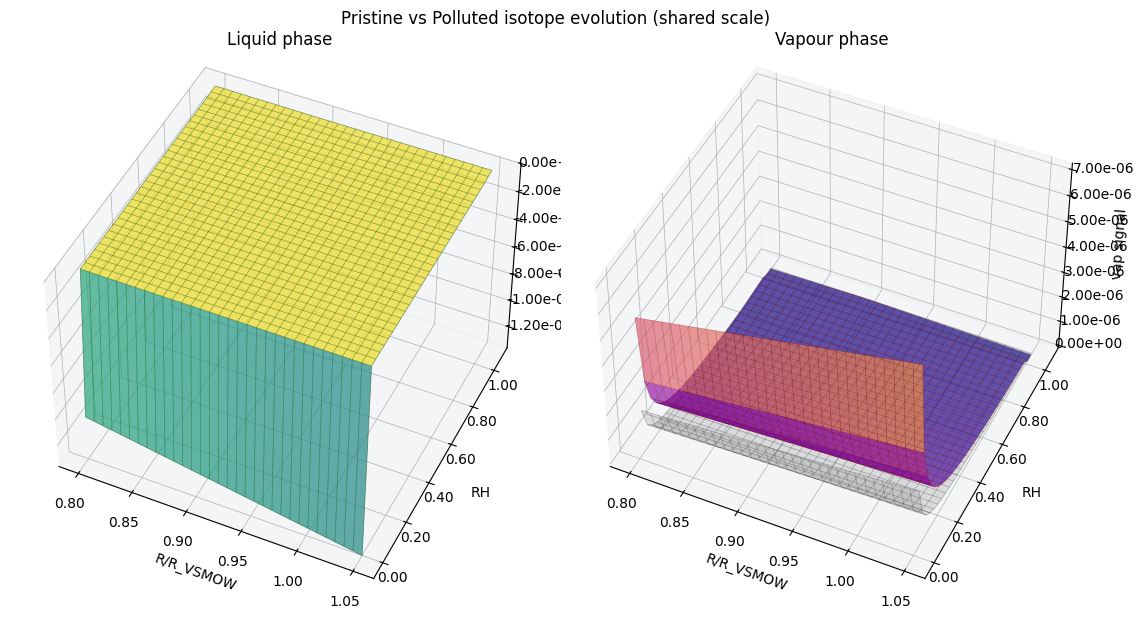

In [6]:
plot_pristine_vs_polluted(
    vap_pristine, liq_pristine,
    vap_polluted, liq_polluted,
    grid_rh, grid_R,
)

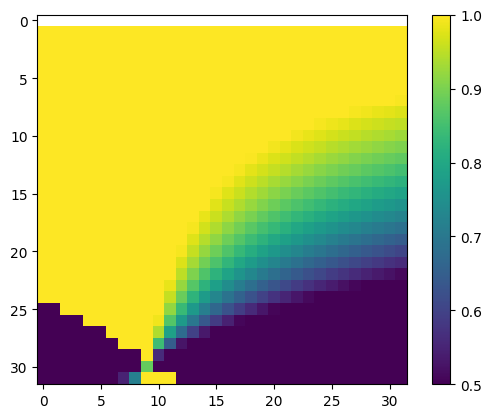

In [7]:
pyplot.imshow(Bo_polluted, vmin=0.5, vmax=1)
pyplot.colorbar()